
**-----PROJEKT--GRUPP6-----** <br>
Pär Hedström<br>
Fredrik Domert Eriksson<br>
Rickard Andersson<br>

# Data Collection Spider<br>
Jag har gjort ett försök till att bygga en Spider som utför Web Scraping. Den simulerar en mänsklig användare för att hämta strukturerad data från en databas. Eller i det här fallet en webbsida. Jag har byggt den ganska generellt just med filter-valen, det kan vi ju ändra lite som vi vill sen när vi är överens. Men den fungerar bra. Den laddar ner en csv-fil i en mapp (data_folder) som skapas i den mapp där jupyter-filen ligger. När man kör koden så kommer hemsidan upp och sen tar det kanske 10 sek innan den skriver i sökfältet. /RA

In [4]:
# Använt kod från https://www.geeksforgeeks.org/web-scraping/scrape-linkedin-using-selenium-and-beautiful-soup-in-python/

# Installerar selenium för att kunna hantera knappar och menyer
%pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Importerar dom bibliotek vi behöver

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import Select
import time
import os

# --- KONFIGURATION & SÖKVÄGAR ---
SEARCH_TERM = "Avsiktligt självdestruktiv handling"
DATA_DIR = os.path.join(os.getcwd())

# Skapar en mapp om den inte redan finns
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

chrome_options = Options()
chrome_options.add_experimental_option("prefs", {
    "download.default_directory": DATA_DIR,
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=chrome_options)
wait = WebDriverWait(driver, 20)

# Här startas sidan (socialstyrelsen) där man kan välja filter och använda sökfältet 
try:
    print(f"Startar sökning. Filer kommer sparas i: {DATA_DIR}")
    driver.get("https://sdb.socialstyrelsen.se/if_dor/val.aspx")

    print("Väljer månadsuppgifter...")
    # Det första vi vill göra är att välja månadsuppgifter då det ändrar filtreringen
    try:
        # Vi letar efter select-elementet inuti diven
        select_ar_manad = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div[id*='armanad_ind'] select"))) # Div-element för År/månadsuppgifter
        s_typer = Select(select_ar_manad)
        s_typer.select_by_visible_text("Månadsuppgifter")
        
        # Trigga sidans eget skript för att rita om gränssnittet till månadsvisning
        driver.execute_script("arguments[0].onchange();", select_ar_manad)
    except Exception as e:
        # Om select-logiken inte fungerar
        print("Kör reservmetod för månadsuppgifter...")
        driver.execute_script("document.querySelector(\"div[id*='armanad_ind'] select\").value = 'm';")
    time.sleep(2.5)

    # Om det ligger gamla val eller text i sökfält så rensas det
    print("Nollställer tidigare val...")
    try:
        rensa = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_dia_id_btnRensaValda"))) # html-element för rensning av val
        driver.execute_script("arguments[0].click();", rensa)
    except:
        pass

    # Använder sökfältet
    print(f"Söker efter: '{SEARCH_TERM}'...")
    sok_falt = wait.until(EC.element_to_be_clickable((By.ID, "Sokord"))) # html-element för sökfält
    sok_falt.clear()
    sok_falt.send_keys(SEARCH_TERM)
    sok_falt.send_keys(Keys.ENTER)

    # Bockar i rutor för sökresultat
    # Har lagt ut några print då det krånglade en del så jag kunde se vart det tog stopp
    print("Markerar diagnosrutor...")
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']"))) # html-element för checkbox sök-resultat
    checkboxar = driver.find_elements(By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']")
    for cb in checkboxar:
        if not cb.is_selected():
            driver.execute_script("arguments[0].click();", cb)
    
    # Filter för Ålder, Kön och månad där vi bockar i Välj alla
    print("Väljer filter...")
    time.sleep(1)
    knappar_att_klicka = [
        "ph1_val_kon_id_hlAdd",    # Välj alla för Kön
        "ph1_val_ar_id_hlAdd",     # Välj alla för År
        "ph1_val_manad_id_hlAdd"   # Välj alla för Månad
    ]
    
    for knap_id in knappar_att_klicka:
        try:
            knapp = driver.find_element(By.ID, knap_id)
            driver.execute_script("arguments[0].click();", knapp)
            time.sleep(0.1)
        except Exception as e:
            print(f"Kunde inte klicka på filter {knap_id}: {e}")

    # Letar upp knappen för Visa resultat
    # Generera tabell och hämta CSV
    print("Genererar tabell...")
    try:
        # Kör javascript-funktionen direkt
        driver.execute_script("submitResultat();")
    except:
        # Backup om JS-anropet krånglar
        visa_lank = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_data_id_lnkVisaResultat"))) # html-element
        driver.execute_script("arguments[0].click();", visa_lank)

    # Nu har vi kommit till resultat-sidan av vår sökning.
    # Högst upp till höger letar vi på csv-länken som laddar ner filen till vår mapp.
    print("Hämtar CSV-fil...")
    csv_knapp = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "a[id$='lbCSV']")))
    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", csv_knapp)
    time.sleep(0.5)
    csv_knapp.click()
    
    print(f"KLART! Din data ligger nu i din mapp.")
    time.sleep(2) # Tid för Chrome då det gick lite för fort tidigare

except Exception as e:
    print(f"Ett fel uppstod: {e}")

# Stänger ner sidan när allt är klart
finally:
    # Vi kollar om driver existerar innan vi försöker stänga den
    if 'driver' in locals() or 'driver' in globals():
        try:
            driver.close() # Stänger fliken
            driver.quit()  # Stänger hela programmet
            print("Webbläsaren stängdes korrekt.")
        except:
            pass # Om den redan var stängd gör vi ingenting

Startar sökning. Filer kommer sparas i: c:\Users\pheds\OneDrive\Desktop\Studier\År 2\Termin 2\DataScience-ML-GIK2KM\Projekt\projekt-grupp6
Väljer månadsuppgifter...
Kör reservmetod för månadsuppgifter...
Nollställer tidigare val...
Söker efter: 'Avsiktligt självdestruktiv handling'...
Markerar diagnosrutor...
Väljer filter...
Genererar tabell...
Hämtar CSV-fil...
KLART! Din data ligger nu i din mapp.
Webbläsaren stängdes korrekt.


# Data-Analys pre-processing

In [6]:
import pandas as pd
import numpy as np

# Vi laddar in den nedladdade filen och kollar på dess struktur för att kunna rensa den ordentligt
file_name = os.path.join("Statistikdatabasen_2026-05-28 12_03_45.csv")

# spar den i en datafram, och hoppar över första raden högst upp.
# Såg i excel att det bara innehåller metadata där
df = pd.read_csv(file_name, sep=';', encoding='utf-8', skiprows=1)

# kollar på den
print("--- HEAD ---") 
print(df.head(15))
print("\n--- INFO ---")
print(df.info())

--- HEAD ---
                                            Kön  Januari 1997  Februari 1997  \
0                                           Män          82.0           70.0   
1                                       Kvinnor          22.0           29.0   
2                                    Båda könen         104.0           99.0   
3  Socialstyrelsens statistikdatabas 2026-05-28           NaN            NaN   

   Mars 1997  April 1997  Maj 1997  Juni 1997  Juli 1997  Augusti 1997  \
0       73.0        67.0      74.0       75.0       72.0          82.0   
1       40.0        26.0      27.0       32.0       24.0          32.0   
2      113.0        93.0     101.0      107.0       96.0         114.0   
3        NaN         NaN       NaN        NaN        NaN           NaN   

   September 1997  ...  Maj 2025  Juni 2025  Juli 2025  Augusti 2025  \
0            54.0  ...      75.0       53.0       80.0          89.0   
1            24.0  ...      15.0       24.0       37.0          34.0   

Här kan vi se att dels gar vi en rad längst ner på index 3 vi kan ta bort.

Sen har vi också månad och År i samma column, det vill vi dela upp.

2026 finns med med ingen data så den ska vi nog ta bort, likaså 2025 som inte är fullständig

In [7]:
# Rensar bort socialstyrelsen... Alla NaN längst ner (Behåller det vi vill ha)
df = df[df['Kön'].isin(['Män', 'Kvinnor', 'Båda könen'])]

# kollar på den
print("--- HEAD ---") 
print(df.head(15))
print("\n--- INFO ---")
print(df.info())


--- HEAD ---
          Kön  Januari 1997  Februari 1997  Mars 1997  April 1997  Maj 1997  \
0         Män          82.0           70.0       73.0        67.0      74.0   
1     Kvinnor          22.0           29.0       40.0        26.0      27.0   
2  Båda könen         104.0           99.0      113.0        93.0     101.0   

   Juni 1997  Juli 1997  Augusti 1997  September 1997  ...  Maj 2025  \
0       75.0       72.0          82.0            54.0  ...      75.0   
1       32.0       24.0          32.0            24.0  ...      15.0   
2      107.0       96.0         114.0            78.0  ...      90.0   

   Juni 2025  Juli 2025  Augusti 2025  September 2025  Oktober 2025  \
0       53.0       80.0          89.0            70.0          65.0   
1       24.0       37.0          34.0            34.0          28.0   
2       77.0      117.0         123.0           104.0          93.0   

   November 2025  December 2025  Januari 2026  Februari 2026  
0             ­­             ­­  

In [13]:
# Nu ska vi separera år och månad.

# Vi måste omvandla från brett till långt format (tidsserieteknik)
# Detta gör att alla "Januari 1997", "Februari 1997" hamnar i en och samma kolumn som vi kallar 'Period'
df_long = df.melt(id_vars=['Kön'], var_name='Period', value_name='Antal')

# Splittar kolumnen 'Period' vid mellanslaget ("Januari" och "1997")
df_long[['Månad', 'År']] = df_long['Period'].str.split(' ', expand=True)

# Tar bort den gamla 'Period'-kolumnen och snygga till ordningen
df_final = df_long[['Kön', 'År', 'Månad', 'Antal']]

# Visa resultatet
print("--- NY STRUKTUR ---")
print(df_final.head(10))
print("\n--- INFO ---")
print(df_final.info())

--- NY STRUKTUR ---
          Kön    År     Månad  Antal
0         Män  1997   Januari   82.0
1     Kvinnor  1997   Januari   22.0
2  Båda könen  1997   Januari  104.0
3         Män  1997  Februari   70.0
4     Kvinnor  1997  Februari   29.0
5  Båda könen  1997  Februari   99.0
6         Män  1997      Mars   73.0
7     Kvinnor  1997      Mars   40.0
8  Båda könen  1997      Mars  113.0
9         Män  1997     April   67.0

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Kön     1050 non-null   object
 1   År      1050 non-null   object
 2   Månad   1050 non-null   object
 3   Antal   1050 non-null   object
dtypes: object(4)
memory usage: 32.9+ KB
None


I info ser vi att det står "object" på alla kolumner vid Dtype, vilket betyder att panda
tolkar allt som strings, både år och antal. Det lär vi rätta till för att kunna plotta.  

In [15]:
# Konvertera År till int
df_final['År'] = df_final['År'].astype(int)

# Konvertera Antal till numeriskt då det fins NaN värden. Går ej att konvertera till int.
df_final['Antal'] = pd.to_numeric(df_final['Antal'], errors='coerce')

# Ersätt alla NaN med 0
df_final['Antal'] = df_final['Antal'].fillna(0)

# Nu går det att konvertera till vanligt heltal
df_final['Antal'] = df_final['Antal'].astype(int)

# tar bort 2025 och 2026 frår datasetet.
df_final = df_final[df_final['År'] < 2025]

# Visa resultatet
print("--- NY STRUKTUR ---")
print(df_final.head(10))
print("\n--- INFO ---")
print(df_final.info())
print()
print("Nu kan vi se att antal och år är Int")

--- NY STRUKTUR ---
          Kön    År     Månad  Antal
0         Män  1997   Januari     82
1     Kvinnor  1997   Januari     22
2  Båda könen  1997   Januari    104
3         Män  1997  Februari     70
4     Kvinnor  1997  Februari     29
5  Båda könen  1997  Februari     99
6         Män  1997      Mars     73
7     Kvinnor  1997      Mars     40
8  Båda könen  1997      Mars    113
9         Män  1997     April     67

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
Index: 1008 entries, 0 to 1007
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Kön     1008 non-null   object
 1   År      1008 non-null   int64 
 2   Månad   1008 non-null   object
 3   Antal   1008 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 39.4+ KB
None

Nu kan vi se att antal och år är Int


# Visualisering

**Tror inte vi behöver dessa diagram?**

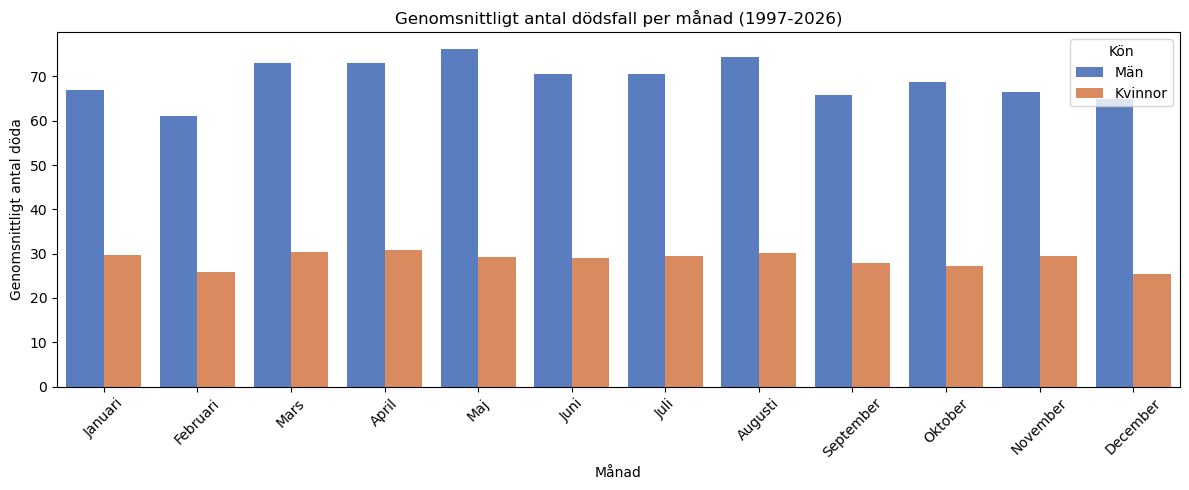

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Filtrera bort "Båda könen" så vi kan jämföra Män och Kvinnor direkt
df_kön = df_final[df_final['Kön'] != 'Båda könen'].dropna()

# Sortera månaderna korrekt chronologiskt
manad_ordning = ["Januari", "Februari", "Mars", "April", "Maj", "Juni", 
                 "Juli", "Augusti", "September", "Oktober", "November", "December"]
sasong_ordning = ["Vinter", "Vår", "Sommar", "Höst"]

# --- VISUALISERING 1: Per Månad ---
plt.figure(figsize=(12, 5))
sns.barplot(data=df_kön, x='Månad', y='Antal', hue='Kön', order=manad_ordning, errorbar=None, palette="muted")
plt.title("Genomsnittligt antal dödsfall per månad (1997-2026)")
plt.ylabel("Genomsnittligt antal döda")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("suicide_per_month.png")
plt.show()



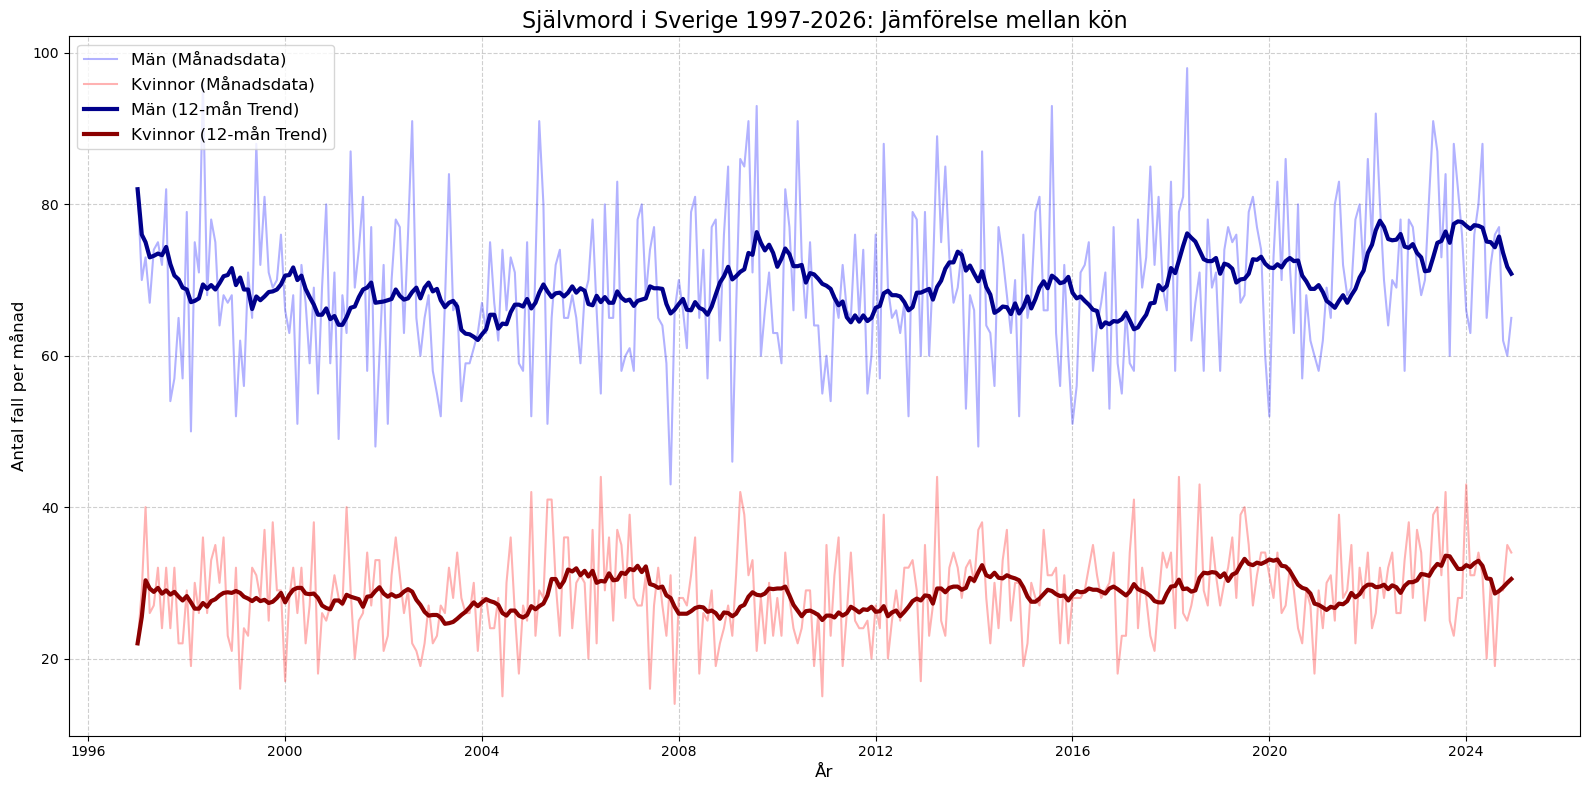

In [17]:
import matplotlib.pyplot as plt


# --- STEG 0: SKAPA EN RIKTIG DATUMKOLUMN (Viktigt för x-axeln) ---
# Vi mappar de svenska månaderna till siffror så att pandas förstår dem
manads_mappning = {
    'Januari': '01', 'Februari': '02', 'Mars': '03', 'April': '04',
    'Maj': '05', 'Juni': '06', 'Juli': '07', 'Augusti': '08',
    'September': '09', 'Oktober': '10', 'November': '11', 'December': '12'
}
# Skapa en temporär sträng t.ex. "1997-01-01" och gör om till datetime
df_final['Månad_Siffra'] = df_final['Månad'].map(manads_mappning)
df_final['Datum'] = pd.to_datetime(df_final['År'].astype(str) + '-' + df_final['Månad_Siffra'] + '-01')

# Sortera datan efter datum så att det rullande medelvärdet räknas i rätt ordning
df_final = df_final.sort_values('Datum')


# --- STEG 1: FILTRERA UT DATA FÖR MÄN OCH KVINNOR ---
df_men = df_final[df_final['Kön'] == 'Män'].copy()
df_women = df_final[df_final['Kön'] == 'Kvinnor'].copy()


# --- STEG 2: BERÄKNA 12-MÅNADERS RULLANDE MEDELVÄRDE ---
# min_periods=1 gör att vi får linjer direkt, även innan vi har 12 hela månader insamlade
df_men['Trend_12m'] = df_men['Antal'].rolling(window=12, min_periods=1).mean()
df_women['Trend_12m'] = df_women['Antal'].rolling(window=12, min_periods=1).mean()


# --- STEG 3: BYGG UPP GRAFEN ---
plt.figure(figsize=(16, 8))

# Plotta den hoppiga månadsdatan lite transparent i bakgrunden (alpha=0.3)
# Vi använder nu vår nya 'Datum'-kolumn på x-axeln
plt.plot(df_men['Datum'], df_men['Antal'], color='blue', alpha=0.3, label='Män (Månadsdata)')
plt.plot(df_women['Datum'], df_women['Antal'], color='red', alpha=0.3, label='Kvinnor (Månadsdata)')

# Plotta de tydliga trendlinjerna starkare ovanpå
plt.plot(df_men['Datum'], df_men['Trend_12m'], color='darkblue', linewidth=3, label='Män (12-mån Trend)')
plt.plot(df_women['Datum'], df_women['Trend_12m'], color='darkred', linewidth=3, label='Kvinnor (12-mån Trend)')

# Formatering av grafen
plt.title('Självmord i Sverige 1997-2026: Jämförelse mellan kön', fontsize=16)
plt.xlabel('År', fontsize=12)
plt.ylabel('Antal fall per månad', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

# Visa grafen
plt.show()